In [27]:
import torch
import torch.nn.functional as F
import numpy as np
import os
import math

from typing import Optional, Union

from diffusion import immap2p5
from training.common import load_model
from datasets.fastmri.common import load_knee_data
from operators import Mask, Sense, FFT2D, Identity
from operators.fourier import fftc, ifftc
from physics.mask import make_acc_mask
from visualization.image import plot_image
from physics.nle import whiten_from_kspace
from physics.smaps import espirit
from solvers import cg
from solvers.rest import rest_prox as rest
from utils.tensor import truncate

In [2]:
def modulate_sensitivity_maps(
    sens_maps: torch.Tensor,
    smooth_sigma: float = 2.0,
    modulation_strength: float = 0.1,
    mode: str = "gaussian",
) -> torch.Tensor:
    """
    Smoothly modulates a set of MRI sensitivity maps.

    Args:
        sens_maps:            Input sensitivity maps of shape (B, C, H, W),
                              can be real or complex.
        smooth_sigma:         Sigma (in pixels) for Gaussian smoothing of the
                              modulation field. Higher = smoother modulation.
        modulation_strength:  Scale of the modulation (0 = no change, 1 = full
                              amplitude variation).
        mode:                 Modulation type:
                                "gaussian"  – smooth random field via Gaussian blur
                                "sinusoidal"– low-frequency sine/cosine field
                                "radial"    – smooth radial gradient from centre

    Returns:
        Modulated sensitivity maps with the same shape and dtype as the input,
        re-normalised so the RSS across coils is preserved.
    """
    if sens_maps.ndim != 4:
        raise ValueError(f"Expected shape (B, C, H, W), got {sens_maps.shape}")

    B, C, H, W = sens_maps.shape
    is_complex = sens_maps.is_complex()
    device = sens_maps.device
    dtype = sens_maps.dtype

    rng = torch.Generator(device=device)

    # ------------------------------------------------------------------ #
    # 1. Build a smooth spatial modulation field  M  of shape (B, 1, H, W)
    #    with values near 1.0 (so the maps stay close to their originals).
    # ------------------------------------------------------------------ #
    if mode == "gaussian":
        # Random noise → Gaussian blur → rescale to [1-s, 1+s]
        noise = torch.rand(B, 1, H, W, device=device, generator=rng) * 2 - 1  # [-1, 1]
        field = _gaussian_blur(noise, sigma=smooth_sigma)
        field = field / (field.abs().amax(dim=(-2, -1), keepdim=True) + 1e-8)
        modulation = 1.0 + modulation_strength * field

    elif mode == "sinusoidal":
        # Superposition of a few low-frequency sinusoids
        ys = torch.linspace(0, 2 * np.pi, H, device=device)
        xs = torch.linspace(0, 2 * np.pi, W, device=device)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing="ij")  # (H, W)

        # Random frequency (1–3 cycles) and phase per batch element
        freqs = torch.randint(1, 4, (B, 2), generator=rng, device=device).float()
        phases = torch.rand(B, 2, generator=rng, device=device) * 2 * np.pi

        field = (
            torch.sin(freqs[:, 0, None, None] * grid_y + phases[:, 0, None, None])
            + torch.cos(freqs[:, 1, None, None] * grid_x + phases[:, 1, None, None])
        ) / 2.0  # (B, H, W), range ≈ [-1, 1]

        modulation = (1.0 + modulation_strength * field).unsqueeze(1)  # (B,1,H,W)

    elif mode == "radial":
        # Smooth radial field: centre bright / dark, fading toward edges
        ys = torch.linspace(-1, 1, H, device=device)
        xs = torch.linspace(-1, 1, W, device=device)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing="ij")
        radius = torch.sqrt(grid_y**2 + grid_x**2)  # (H, W)
        # Random sign per batch (bright-centre vs dark-centre)
        signs = (torch.randint(0, 2, (B,), generator=rng, device=device) * 2 - 1).float()
        field = signs[:, None, None] * (1 - radius / radius.max())  # (B, H, W)
        modulation = (1.0 + modulation_strength * field).unsqueeze(1)  # (B,1,H,W)

    else:
        raise ValueError(f"Unknown mode '{mode}'. Choose: gaussian | sinusoidal | radial")

    # ------------------------------------------------------------------ #
    # 2. Apply modulation to (complex or real) sensitivity maps
    # ------------------------------------------------------------------ #
    if is_complex:
        # Modulate magnitude only, preserve phase
        magnitude = sens_maps.abs()
        phase = torch.angle(sens_maps)
        new_magnitude = magnitude * modulation.to(magnitude.dtype)
        modulated = torch.polar(new_magnitude, phase)
    else:
        modulated = sens_maps * modulation.to(dtype)

    # ------------------------------------------------------------------ #
    # 3. Renormalise: preserve the original RSS profile across coils
    # ------------------------------------------------------------------ #
    if is_complex:
        orig_rss = sens_maps.abs().pow(2).sum(dim=1, keepdim=True).sqrt()   # (B,1,H,W)
        new_rss = modulated.abs().pow(2).sum(dim=1, keepdim=True).sqrt()
    else:
        orig_rss = sens_maps.pow(2).sum(dim=1, keepdim=True).sqrt()
        new_rss = modulated.pow(2).sum(dim=1, keepdim=True).sqrt()

    scale = orig_rss / (new_rss + 1e-8)
    modulated = modulated * scale

    return modulated.to(dtype)


# ------------------------------------------------------------------ #
# Helper: separable Gaussian blur (no external deps beyond PyTorch)
# ------------------------------------------------------------------ #
def _gaussian_blur(x: torch.Tensor, sigma: float) -> torch.Tensor:
    """Apply separable Gaussian blur to a (B, C, H, W) tensor."""
    radius = int(3 * sigma + 0.5)
    ks = 2 * radius + 1
    t = torch.arange(ks, device=x.device, dtype=torch.float32) - radius
    kernel_1d = torch.exp(-0.5 * (t / sigma) ** 2)
    kernel_1d = kernel_1d / kernel_1d.sum()

    C = x.shape[1]
    # Horizontal pass
    kh = kernel_1d.view(1, 1, 1, ks).expand(C, 1, 1, ks)
    x = F.conv2d(x, kh, padding=(0, radius), groups=C)
    # Vertical pass
    kv = kernel_1d.view(1, 1, ks, 1).expand(C, 1, ks, 1)
    x = F.conv2d(x, kv, padding=(radius, 0), groups=C)
    return x

In [3]:
os.chdir('/scratch/ee2178/ImMAP')

In [4]:
# GPU Settings
device = 'cuda'

In [5]:
fname = "file1000264.h5"
kspace, smaps, knee_mask, gnd_truth = load_knee_data(kspace_fname = fname, slice_idx=15, device=device)

Loading slice 15 from /home/ee2178/scratch/ee2178/datasets/fastmri/knee/multicoil_val/file1000264.h5


In [6]:
# Mask generation
mask = make_acc_mask(shape=kspace[0,0].shape, accel = 6, acs_lines=20, device = device)

In [7]:
# Try whitening first
kspace_w, image_w, smaps_w, sigma_n, smaps_w, Zinv = whiten_from_kspace(kspace, smaps, mask = mask, R = 6, gnd_truth_kspace = kspace)

In [8]:
# Construct operator
E = Mask(mask) @ FFT2D() @ Sense(smaps)

In [20]:
meas_kspace = mask*kspace
sim_kspace = E(E.H(kspace))

In [39]:
# Sensitivity map modulation
smaps_mod = modulate_sensitivity_maps(
    smaps, 
    smooth_sigma = 2.0,
    modulation_strength = 5.0,
    mode = "gaussian",
)

In [10]:
# Mimicking ImMAP2 iterations (load denoiser)
# LPDSNet Checkpoint
denoiser_path = '/home/ee2178/scratch/ee2178/ImMAP/trained_nets/knee/LPDSNet/config.json'
net = load_model(denoiser_path, device=device)

In [ ]:
# Hyperparameter settings
l = 0.01
E = Mask(mask) @ FFT2D() @ Sense(smaps)
# CG Sense with simulated vs measurement kspace
def A(x, E=E, l=l):
    return E.normal(x) + l*x
# Attempt CG with simulated kspace
# y = E(E.H(kspace)) # Sim
y = mask*kspace # measurement

# Sample random x
sigma = 1.0
x = sigma * torch.randn_like(E.H(y))
x_hat, _ = net(x, Identity(), sigma)

v_cg, tol_reached = cg(A, l*x_hat+E.H(y), max_iter = 500, tol=1e-3, verbose = False)
print(tol_reached)
plot_image(v_cg)

True


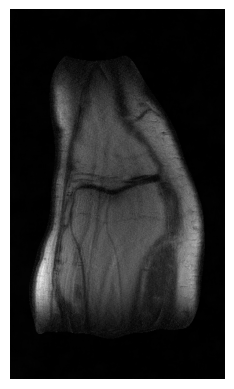

In [11]:
# Hyperparameter settings
l = 0.01
E = Mask(mask) @ FFT2D() @ Sense(smaps)
# CG Sense with simulated vs measurement kspace
def A(x, E=E, l=l):
    return E.normal(x) + l*x
# Attempt CG with simulated kspace
# y = E(E.H(kspace)) # Sim
y = mask*kspace # measurement

# Sample random x
sigma = 1.0
x = sigma * torch.randn_like(E.H(y))
x_hat, _ = net(x, Identity(), sigma)

v_cg, tol_reached = cg(A, l*x_hat+E.H(y), max_iter = 500, tol=1e-3, verbose = False)
print(tol_reached)
plot_image(v_cg)

True


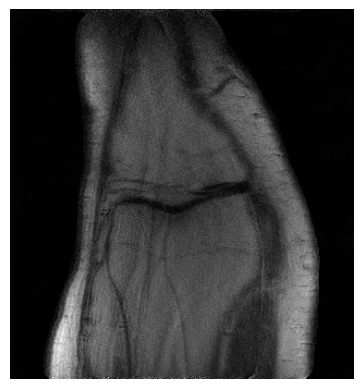

In [12]:
# kspace truncation experiment. try taking a 1D FFT in the readout dimension and truncating 
y = mask*kspace
Y = ifftc(y, dim = 2, mode = 'ortho', real = False)
# clip along readout
trunc_start = 100
trunc_end = 500
Y_trunc = truncate(Y, trunc_start, trunc_end, dim = 2)
# Go back to kspace
y_trunc = fftc(Y_trunc, dim = 2, mode = 'ortho', real = False)
# truncate mask too
mask_trunc = truncate(mask, trunc_start, trunc_end, dim = 2)
# Reestimate smaps
smaps_trunc = espirit(
    y_trunc,
    acs_size = (20, 20),
    kernel_size = 8,
    thresh_rowspace = 0.01,
    thresh_eig = 0.99
)

# Need to flip in last 2 dims
smaps_trunc = torch.flip(smaps_trunc, dims = (-2, -1))
# Operator construction
l = 0.01
E_trunc = Mask(mask_trunc) @ FFT2D() @ Sense(smaps_trunc)
def A(x, E=E_trunc, l=l):
    return E.normal(x) + l*x

# Sample random x
sigma = 1.0
x = sigma * torch.randn_like(E_trunc.H(y_trunc))
x_hat, _ = net(x, Identity(), sigma)

v_cg, tol_reached = cg(A, l*x_hat+E_trunc.H(y_trunc), max_iter = 500, tol=1e-3, verbose = False)
print(tol_reached)
plot_image(v_cg)

In [28]:
@torch.no_grad()
def random_phase_map(
    height: int,
    width: int,
    batch: int = 1,
    correlation_length: float = 16.0,
    phase_std: float = 1.0,
    wrap: bool = False,
    device: Union[torch.device, str] = "cpu",
    dtype: torch.dtype = torch.float32,
    seed: Optional[int] = None,
) -> torch.Tensor:
    """
    Generate smoothly varying complex phase maps: fields of the form exp(i*phi),
    where phi is a spatially-correlated Gaussian random field.

    Args:
        height, width:      Spatial dimensions (H, W).
        batch:              Number of independent maps B.
        correlation_length: Smoothness scale in pixels. Larger -> smoother / slower
                            spatial variation. This is the std of the equivalent
                            real-space Gaussian smoothing kernel.
        phase_std:          Std of the phase field in radians (overall amplitude).
        wrap:               If True, wrap phase into (-pi, pi]. If False, leave the
                            raw Gaussian field (keeps exp() smooth for small phase_std).
        device, dtype:      Standard torch placement / precision.
        seed:               Optional RNG seed for reproducibility.

    Returns:
        field: Complex tensor of shape (B, H, W), unit magnitude, dtype complex64/128.
    """
    B, H, W = batch, height, width
    device = torch.device(device)

    gen = None
    if seed is not None:
        gen = torch.Generator(device=device).manual_seed(seed)

    # --- White Gaussian noise in real space ---
    noise = torch.randn(B, H, W, generator=gen, device=device, dtype=dtype)

    # --- Fourier-domain Gaussian low-pass filter ---
    # fftfreq gives spatial frequency in cycles/pixel.
    fy = torch.fft.fftfreq(H, device=device, dtype=dtype).view(1, H, 1)   # (1,H,1)
    fx = torch.fft.fftfreq(W, device=device, dtype=dtype).view(1, 1, W)   # (1,1,W)
    f2 = fx.pow(2) + fy.pow(2)                                            # (1,H,W)

    # FT of a real-space Gaussian with std sigma (pixels): exp(-2*pi^2 * sigma^2 * f^2)
    sigma = correlation_length
    filt = torch.exp(-2.0 * (math.pi ** 2) * (sigma ** 2) * f2)          # (1,H,W)

    # --- Filter the noise, return to real space ---
    F = torch.fft.fft2(noise)
    smooth = torch.fft.ifft2(F * filt).real                              # (B,H,W)

    # --- Normalize to unit std (per-map), then scale to desired amplitude ---
    smooth = smooth - smooth.mean(dim=(-2, -1), keepdim=True)
    std = smooth.std(dim=(-2, -1), keepdim=True).clamp(min=1e-12)
    phase = smooth / std * phase_std                                     # (B,H,W)

    if wrap:
        # Wrap into (-pi, pi]
        phase = (phase + math.pi) % (2 * math.pi) - math.pi

    # --- Build the complex field exp(i*phi) ---
    field = torch.polar(torch.ones_like(phase), phase)                  # complex

    return field

In [32]:
# Generate random phase map
phase_map = random_phase_map(height = kspace.shape[-2], width = kspace.shape[-1], device = device)

True


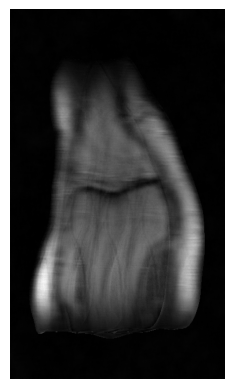

In [33]:
# The difference maps below show that there is definitely a Fourier perturbation issue here. Some images appear shifted in the image domain after coil combination...
# Let's try to replicate this

# Try multiplying sim_kspace by a phase map elementwise. 

# Hyperparameter settings
l = 0.01
E = Mask(mask) @ FFT2D() @ Sense(smaps)
# CG Sense with simulated vs measurement kspace
def A(x, E=E, l=l):
    return E.normal(x) + l*x
# Attempt CG with simulated kspace
# y = E(E.H(kspace))*phase_map # Sim
# Multiply KSPACE with a phase map. 

# y = mask*kspace # measurement

# Sample random x
sigma = 1.0
x = sigma * torch.randn_like(E.H(y))
x_hat, _ = net(x, Identity(), sigma)

v_cg, tol_reached = cg(A, l*x_hat+E.H(y), max_iter = 500, tol=1e-3, verbose = False)
print(tol_reached)
plot_image(v_cg)

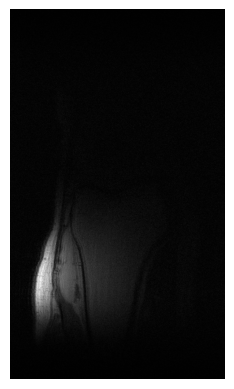

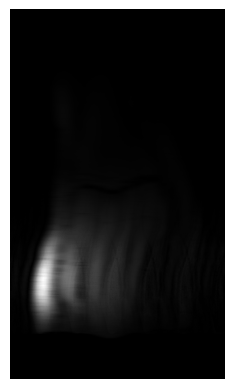

In [36]:
plot_image(ifftc(meas_kspace[0, 1, :, :]))
plot_image(ifftc(sim_kspace[0, 1, :, :]))

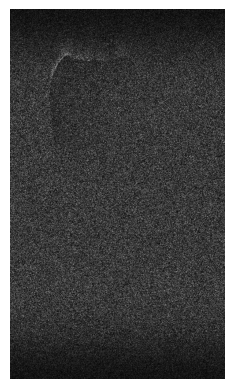

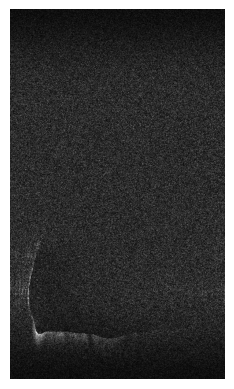

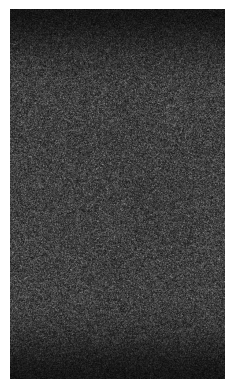

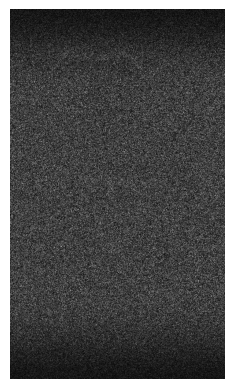

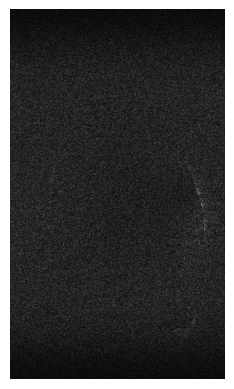

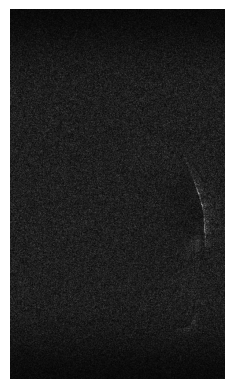

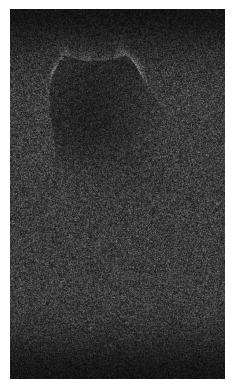

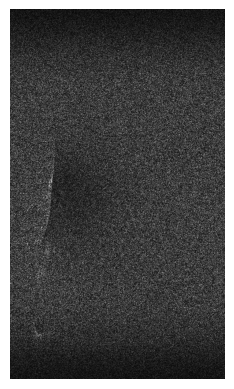

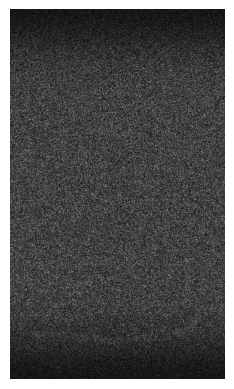

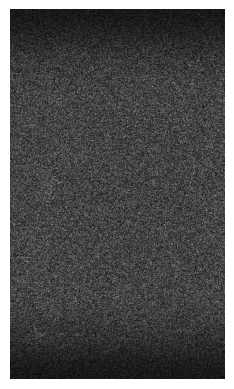

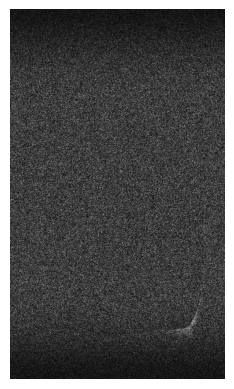

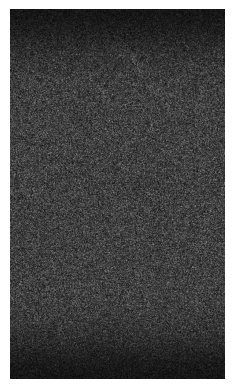

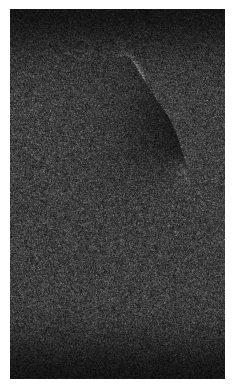

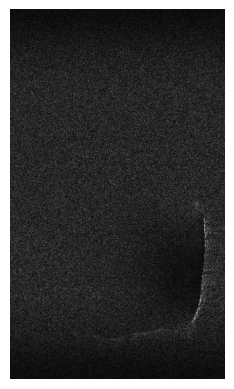

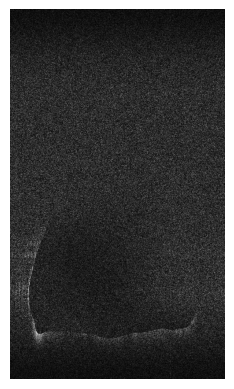

In [42]:
# Visualizing each coil
s = 14
# Pretend like there's no masking
mask = torch.ones_like(smaps[:, 0, :, :])
E = Mask(mask) @ FFT2D() @ Sense(smaps_mod)
meas_kspace = kspace
sim_kspace = E(E.H(kspace))

for i in range(kspace.shape[1]):
    plot_image(ifftc(meas_kspace[0, i, :, :])-ifftc(sim_kspace[0, i, :, :]))
    # plot_image(F.H(sim_kspace[0, i, :, :]))
    # plot_image((smaps_trunc[0, i, :, :])-truncate(smaps, trunc_start, trunc_end, dim = 2)[0, i, :, :])
    # plot_image((smaps_mod-smaps)[0, i, :, :])